# 04 — Time Matrix (Waktu Tempuh Antar Venue)

**Beda dari `time_spent`** (durasi kunjungan DI dalam satu venue, sintetis):
`time_matrix` = waktu tempuh DARI satu venue KE venue lain — dipakai
sebagai constraint fitness GA/PSO (next phase, optimasi rute itinerary).

**Sumber waktu tempuh** (kolom `time_source`):
1. **OSRM** (`router.project-osrm.org`) — rute jalan asli, durasi dari
   response API. Gratis, tanpa API key, TANPA traffic real-time.
2. **Estimated** (fallback) — `haversine / avg_speed_kmh` (asumsi 20 km/jam,
   kondisi macet Jakarta), dipakai kalau OSRM gagal/timeout.

**Dua matrix** (219 venue final):
- `jakarta_travel_time_inzone.csv` — **3.912 pasangan** in-zone (zone_id sama,
  hasil clustering 03). Fitness penalty in-zone GA/PSO.
- `jakarta_travel_time_allpairs.csv` — **23.871 pasangan** all-pairs (nC2 penuh).
  Lookup cross-zone GA/PSO. User bebas pilih venue lintas zona (soft constraint).

Notebook ini analisis in-zone; allpairs punya distribusi serupa.

In [1]:
import os, sys, time, itertools
from math import radians, sin, cos, asin, sqrt
# ROOT idempoten: jangan naik lagi kalau sudah di root (aman run berulang)
if not os.path.exists("config.py"):
    os.chdir(os.path.abspath(".."))
sys.path.insert(0, os.getcwd())

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
import config

print("Root:", os.getcwd())


def _haversine_m(lat1, lon1, lat2, lon2):
    """Jarak great-circle (meter)."""
    r = 6371000.0
    dlat, dlon = radians(lat2 - lat1), radians(lon2 - lon1)
    x = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    return 2 * r * asin(sqrt(x))


def osrm_duration_minutes(lat1, lon1, lat2, lon2, timeout=10):
    """OSRM /route → durasi menit. None kalau gagal."""
    url = f"{config.OSRM_BASE_URL}/route/v1/driving/{lon1},{lat1};{lon2},{lat2}"
    try:
        resp = requests.get(url, params={"overview": "false"}, timeout=timeout)
        if resp.status_code != 200:
            return None
        data = resp.json()
        if data.get("code") != "Ok":
            return None
        return data["routes"][0]["duration"] / 60.0
    except requests.RequestException:
        return None


def estimate_duration_minutes(lat1, lon1, lat2, lon2):
    """Fallback: haversine / avg_speed_kmh (estimasi macet Jakarta)."""
    dist_km = _haversine_m(lat1, lon1, lat2, lon2) / 1000.0
    return (dist_km / config.AVG_SPEED_KMH_FALLBACK) * 60.0

Root: D:\humic\sistem rekomendasi destinasi wisata jakarta


## [RUN] Build time matrix (OSRM)

Butuh **internet** (OSRM public demo). Cache-aware & resume-able: pasangan yang
sudah dihitung tidak di-query ulang. In-zone ~3.912 pasangan, all-pairs ~23.871
pasangan — sleep 0.5s antar request (all-pairs bisa lama). Hapus file output untuk
rebuild dari nol.

In [2]:
# [RUN] In-zone time matrix (inline dari build_time_matrix.py)
def build_time_matrix(all_pairs=False):
    """all_pairs=False → in-zone (zone sama); True → semua kombinasi nC2."""
    out_csv = config.TIME_MATRIX_ALLPAIRS_CSV if all_pairs else config.TIME_MATRIX_CSV
    df = pd.read_csv(config.CLUSTERED_VENUES_CSV)
    df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
    df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
    df = df.dropna(subset=["latitude", "longitude"]).drop_duplicates(subset=["venue_id"])
    print(f"Venue input (clustered): {len(df)}")

    if all_pairs:
        pairs = list(itertools.combinations(df["venue_id"].tolist(), 2))
    else:
        pairs = []
        for zone in sorted(df["zone_id"].unique()):
            ids = df[df["zone_id"] == zone]["venue_id"].tolist()
            pairs += list(itertools.combinations(ids, 2))
    valid = set(pairs) | {(b, a) for a, b in pairs}
    print(f"Total pasangan {'all-pairs' if all_pairs else 'in-zone'}: {len(pairs)}")

    # Cache: buang stale, seed all-pairs dari in-zone kalau ada
    cache = {}
    if os.path.exists(out_csv):
        prev = pd.read_csv(out_csv)
        for _, r in prev.iterrows():
            if (r["venue_id_a"], r["venue_id_b"]) in valid:
                cache[(r["venue_id_a"], r["venue_id_b"])] = (r["duration_minutes"], r["time_source"])
        print(f"Cache: {len(cache)} pasangan valid.")
    elif all_pairs and os.path.exists(config.TIME_MATRIX_CSV):
        for _, r in pd.read_csv(config.TIME_MATRIX_CSV).iterrows():
            cache[(r["venue_id_a"], r["venue_id_b"])] = (r["duration_minutes"], r["time_source"])
        print(f"Seed dari in-zone: {len(cache)} pasangan.")

    os.makedirs(os.path.dirname(out_csv), exist_ok=True)
    coord = df.set_index("venue_id")[["latitude", "longitude"]].astype(float)
    rows = [{"venue_id_a": a, "venue_id_b": b, "duration_minutes": d, "time_source": s}
            for (a, b), (d, s) in cache.items()
            if (a, b) in valid]
    n_osrm = n_fb = 0
    for a, b in pairs:
        if (a, b) in cache or (b, a) in cache:
            continue
        la1, lo1 = coord.loc[a]; la2, lo2 = coord.loc[b]
        dur = osrm_duration_minutes(la1, lo1, la2, lo2)
        src = "osrm" if dur is not None else "estimated"
        if dur is None:
            dur = estimate_duration_minutes(la1, lo1, la2, lo2); n_fb += 1
        else:
            n_osrm += 1
        dur = round(dur, 1)
        rows.append({"venue_id_a": a, "venue_id_b": b, "duration_minutes": dur, "time_source": src})
        cache[(a, b)] = (dur, src)
        time.sleep(0.5)
        if (n_osrm + n_fb) % 50 == 0:
            pd.DataFrame(rows).to_csv(out_csv, index=False)
            print(f"  progress: {len(rows)}/{len(pairs)} (osrm={n_osrm} fb={n_fb}, flushed)")

    pd.DataFrame(rows).to_csv(out_csv, index=False)
    print(f"Selesai: {len(rows)} pasangan (osrm baru={n_osrm}, fallback={n_fb})")
    print(f"Tersimpan -> {out_csv}")


if os.path.exists(config.TIME_MATRIX_CSV):
    print(f"[skip] {config.TIME_MATRIX_CSV} sudah ada. Hapus untuk rebuild.")
else:
    build_time_matrix(all_pairs=False)

[skip] data/processed/jakarta_travel_time_inzone.csv sudah ada. Hapus untuk rebuild.


In [3]:
# [RUN] All-pairs time matrix (nC2 penuh, lookup cross-zone GA/PSO)
if os.path.exists(config.TIME_MATRIX_ALLPAIRS_CSV):
    print(f"[skip] {config.TIME_MATRIX_ALLPAIRS_CSV} sudah ada. Hapus untuk rebuild.")
else:
    build_time_matrix(all_pairs=True)

[skip] data/processed/jakarta_travel_time_allpairs.csv sudah ada. Hapus untuk rebuild.


In [4]:
tm = pd.read_csv(config.TIME_MATRIX_CSV)
clustered = pd.read_csv(config.CLUSTERED_VENUES_CSV)

print(f"Total pasangan venue in-zone: {len(tm)}")
print()
print("Sumber waktu tempuh:")
print(tm["time_source"].value_counts())
print()
pct_osrm = (tm["time_source"] == "osrm").mean()
print(f"OSRM sukses: {pct_osrm:.1%} | fallback estimasi: {1 - pct_osrm:.1%}")

Total pasangan venue in-zone: 2289

Sumber waktu tempuh:
time_source
osrm    2289
Name: count, dtype: int64

OSRM sukses: 100.0% | fallback estimasi: 0.0%


In [5]:
# Cuplikan time matrix dengan NAMA venue (bukan cuma id) — untuk slide presentasi
name_map = clustered.set_index('venue_id')['name']
tm_named = tm.copy()
tm_named['venue_a'] = tm_named['venue_id_a'].map(name_map)
tm_named['venue_b'] = tm_named['venue_id_b'].map(name_map)
tm_named[['venue_a', 'venue_b', 'duration_minutes', 'time_source']].head(8)

,venue_a,venue_b,duration_minutes,time_source
0,Patung Pemuda Membangun - Bundaran Senayan,Patung Panahan Senayan,3.4,osrm
1,Patung Pemuda Membangun - Bundaran Senayan,Museum Satriamandala,4.8,osrm
2,Patung Pemuda Membangun - Bundaran Senayan,Museum Polri,3.7,osrm
3,Patung Pemuda Membangun - Bundaran Senayan,Klenteng Hian Thian Siang Tee,7.0,osrm
4,Patung Panahan Senayan,Museum Satriamandala,5.4,osrm
5,Patung Panahan Senayan,Museum Polri,5.0,osrm
6,Patung Panahan Senayan,Klenteng Hian Thian Siang Tee,5.5,osrm
7,Museum Satriamandala,Museum Polri,4.0,osrm


## Distribusi waktu tempuh

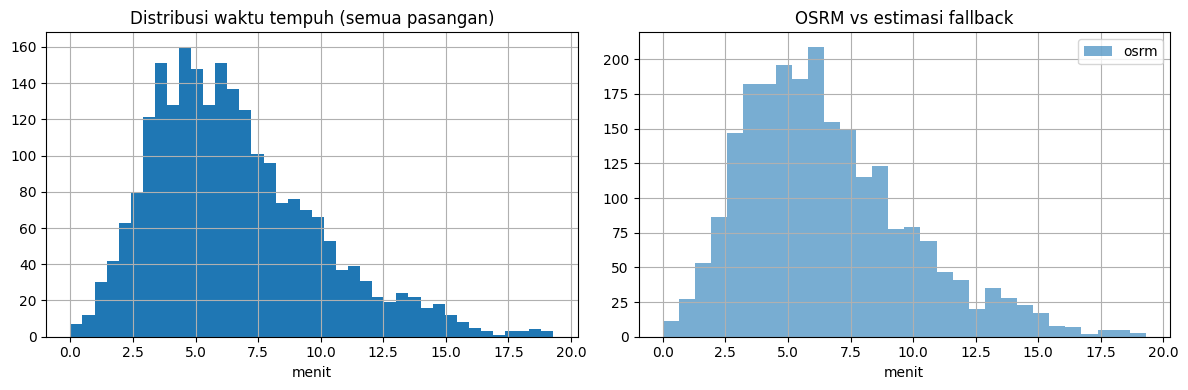

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tm["duration_minutes"].hist(bins=40, ax=axes[0])
axes[0].set_title("Distribusi waktu tempuh (semua pasangan)")
axes[0].set_xlabel("menit")

for src in tm["time_source"].unique():
    tm[tm["time_source"] == src]["duration_minutes"].hist(
        bins=30, ax=axes[1], alpha=0.6, label=src)
axes[1].set_title("OSRM vs estimasi fallback")
axes[1].set_xlabel("menit")
axes[1].legend()
plt.tight_layout()
plt.show()

## Spot-check: OSRM vs estimasi pada pasangan yang sama

Sanity check — waktu tempuh OSRM (rute jalan asli) seharusnya lebih besar
dari estimasi garis lurus (`haversine/speed`) karena jalan tidak lurus.

In [7]:
coord = clustered.set_index("venue_id")[["latitude", "longitude"]]


def haversine_km(a, b):
    from math import radians, sin, cos, asin, sqrt
    lat1, lon1 = coord.loc[a]
    lat2, lon2 = coord.loc[b]
    r = 6371
    dlat, dlon = radians(lat2 - lat1), radians(lon2 - lon1)
    x = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    return 2 * r * asin(sqrt(x))


sample = tm[tm["time_source"] == "osrm"].sample(min(10, len(tm[tm["time_source"] == "osrm"])),
                                                  random_state=config.RANDOM_SEED)
sample = sample.copy()
sample["dist_km"] = sample.apply(lambda r: haversine_km(r["venue_id_a"], r["venue_id_b"]), axis=1)
sample["estimasi_menit"] = sample["dist_km"] / config.AVG_SPEED_KMH_FALLBACK * 60
sample[["venue_id_a", "venue_id_b", "dist_km", "duration_minutes", "estimasi_menit"]]

,venue_id_a,venue_id_b,dist_km,duration_minutes,estimasi_menit
2209,google_00104,manual_trick_art_001,5.314122,10.0,15.942365
543,google_00098,google_00134,5.799590,8.1,17.398769
892,833,google_00095,4.962652,10.3,14.887955
44,783,48485,1.052395,9.8,3.157185
2024,12867,75864,5.948600,9.0,17.845800
290,18109,44851,2.252744,5.0,6.758231
1110,google_00086,google_00100,2.447289,5.6,7.341868
2013,43780,google_00087,2.687866,5.5,8.063598
1010,31626,google_00100,3.346858,7.4,10.040574
367,829,21938,1.941559,5.3,5.824677


## Heatmap waktu tempuh — zona dengan jumlah venue terbanyak

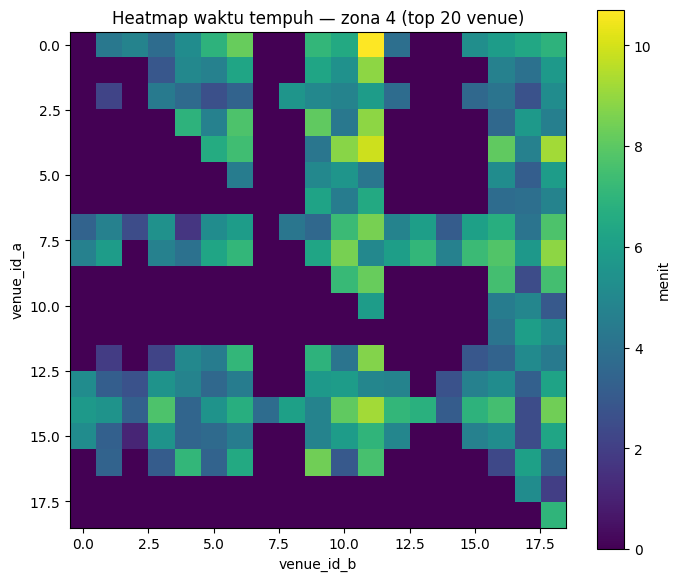

In [8]:
top_zone = clustered["zone_id"].value_counts().idxmax()
ids_zone = clustered[clustered["zone_id"] == top_zone]["venue_id"].tolist()[:20]

sub = tm[tm["venue_id_a"].isin(ids_zone) & tm["venue_id_b"].isin(ids_zone)]
pivot = sub.pivot_table(index="venue_id_a", columns="venue_id_b", values="duration_minutes")

plt.figure(figsize=(8, 7))
plt.imshow(pivot.fillna(0), cmap="viridis")
plt.colorbar(label="menit")
plt.title(f"Heatmap waktu tempuh — zona {top_zone} (top 20 venue)")
plt.xlabel("venue_id_b")
plt.ylabel("venue_id_a")
plt.show()

## Ringkasan

`jakarta_travel_time_inzone.csv` + `jakarta_travel_time_allpairs.csv` siap
dipakai sebagai constraint fitness GA/PSO — total durasi rute =
sum(`time_matrix` antar venue berurutan) + sum(`time_spent` di tiap venue).
**Sudah diimplementasikan** di `src/modeling/problem.py` (`TTDPProblem.decode()`)
dan dipakai GA/PSO/Hybrid di `notebooks/06_optimization.ipynb`.